____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [7]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD

c0 ={'acc':'#941717', 'cor':'#388E3C','ggd':'#42A5F5', 'wd':'#FFA000'}

_______
# Data

In [8]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss1e4', 'swot250gauss5e4', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss1e4', 'swot2kmgauss5e4', 'swot2kmgauss5e3']),
 dict_keys(['era5']))

In [43]:
dtypes = {'drifter_id':str}

def prepared_drifters(drifter_key) : 
    dfr = pd.read_csv(DRIFTER[drifter_key], parse_dates=['datetime'], dtype=dtypes).set_index('row_number')
    dfr['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dfr.latitude * np.pi / 180)
    dfr['core']= -dfr.f * dfr.velocity_north
    dfr['corn']= dfr.f * dfr.velocity_east
    dfr = dfr.rename(columns = {'acceleration_north':'accn', 'acceleration_east':'acce'})
    return dfr[['datetime', 'longitude', 'latitude', 'pass_number','time_to_swot','cycle_number','cycle_date','drifter_id','drifter_type','accn', 'acce', 'core', 'corn']]

def prepared_alti(alti_key, ggd_var=['duacs_ssha_karin_2_filtered','duacs_ssha_karin_2_calibrated','cvl_mean_dynamic_topography_cnes_cls_22','cvl_ocean_tide_fes_2022']) :
    dfs = pd.read_csv(ALTI[alti_key]).set_index('row_number')
    dfs['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dfs.latitude * np.pi / 180)
    dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
    dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs
    dfs = dfs[['ggde_'+v for v in ggd_var]+['ggdn_'+v for v in ggd_var]+['ggde_fromduacsv', 'ggdn_fromduacsv']]
    dfs['ggde_etaf'] = dfs.ggde_duacs_ssha_karin_2_filtered + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggde_cvl_ocean_tide_fes_2022
    dfs['ggdn_etaf'] = dfs.ggdn_duacs_ssha_karin_2_filtered + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggdn_cvl_ocean_tide_fes_2022
    dfs['ggde_adtf'] = dfs.ggde_duacs_ssha_karin_2_filtered + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22
    dfs['ggdn_adtf'] = dfs.ggdn_duacs_ssha_karin_2_filtered + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22
    dfs['ggde_etac'] = dfs.ggde_duacs_ssha_karin_2_calibrated + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggde_cvl_ocean_tide_fes_2022
    dfs['ggdn_etac'] = dfs.ggdn_duacs_ssha_karin_2_calibrated + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggdn_cvl_ocean_tide_fes_2022
    dfs['ggde_adtc'] = dfs.ggde_duacs_ssha_karin_2_calibrated + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22
    dfs['ggdn_adtc'] = dfs.ggdn_duacs_ssha_karin_2_calibrated + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22
    return dfs#.rename(columns ={v : v+'_' +alti_key for v in dfs})
    
def prepared_wd(wd_key): 
    dfw = pd.read_csv(WD[wd_key]).set_index('row_number')
    dfw = dfw[[v for v in dfw if ('wde' in v or 'wdn' in v)]]
    return dfw#.rename(columns ={v : v+'_' +wd_key for v in dfw})

def create_id_comb(drifter_key, alti_key, wd_key = 'era5', ggd_var='etaf', wd_depth='0'):
    return drifter_key + '__' + alti_key +'_' + ggd_var + '__' + wd_depth + wd_key

def select_nearest_swot_coloc(df):
    idx = df.groupby(['pass_number','cycle_number','drifter_id']).time_to_swot.idxmin()
    return df.loc[idx]

def one_coloc(drifter_key, alti_key, wd_key = 'era5', ggd_var='etaf', wd_depth='0'):
    df = pd.concat([prepared_drifters(drifter_key),
                    prepared_alti(alti_key)[['ggde_'+ggd_var,'ggdn_'+ggd_var]].rename(columns = {'ggde_'+ggd_var:'ggde','ggdn_'+ggd_var:'ggdn'}), 
                    prepared_wd(wd_key)[['wde'+wd_depth,'wdn'+wd_depth]].rename(columns = {'wde'+wd_depth : 'wde','wdn'+wd_depth:'wdn'}),
                   ], axis=1)#.dropna() # with dropna, depends on the altimetry filter
    id_comb = create_id_comb(drifter_key, alti_key, wd_key, ggd_var, wd_depth)
    
    #depth
    depth = df['pass_number'].copy()
    depth.loc[df['drifter_type'].isin(surface_drifters)]=0
    depth.loc[df['drifter_type'].isin(depth_drifters)]=15
    depth.loc[df['drifter_id'].isin(depth_50)]=50
    depth.loc[df['drifter_id'].isin(depth_100)]=100

    df['depth'] = depth
    
    return df, id_comb

        
def dataset_coloc_combs(comb_list, nearest =True):
    D = []
    for comb in comb_list :
        df, id_comb = one_coloc(**comb)

        if nearest :
            # select only nearest in time colocalisation
            df = select_nearest_swot_coloc(df).dropna()
            
        coords_list = ['datetime', 'longitude', 'latitude', 'pass_number','time_to_swot','cycle_number','drifter_id', 'drifter_type','depth']
        ds = df[coords_list].to_xarray()
        ds['id_comb'] = id_comb
        
        for direction in ['e', 'n'] : 
            if direction == 'e' : l = {'acc':'acce', 'cor':'core', 'ggd':'ggde', 'wd':'wde'}
            if direction == 'n' : l = {'acc':'accn', 'cor':'corn', 'ggd':'ggdn', 'wd':'wdn'}
                
            # sum 
            ds['sum'+direction] = sum([df[l[v]] for v in l])

            # simple var + sum- one term
            for v in l :
                ds[l[v]] = df[l[v]]
                ds['exc'+direction+'_'+v] = ds['sum'+direction]-ds[l[v]]
                
            #2 by 2 product    
            import itertools  
            couple = list(itertools.combinations(list(l.keys()),2))
            for c in couple : 
                ds['prod'+direction+'_'+'_'.join(c)] = ds[c[0]+direction] * ds[c[1]+direction]
                
        D.append(ds.set_coords('id_comb'))
    return xr.concat(D, dim='id_comb').set_coords(coords_list)

In [44]:
prepared_drifters('nofilter')


,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,cycle_date,drifter_id,drifter_type,accn,acce,core,corn
row_number,,,,,,,,,,,,,
0,2023-04-01 11:50:00,4.811970,42.220893,3,0 days 11:52:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000012,0.000006,-0.000010,0.000006
1,2023-04-01 12:00:00,4.812432,42.221430,3,0 days 11:42:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000012,0.000005,-0.000009,0.000007
2,2023-04-01 12:10:00,4.812916,42.221930,3,0 days 11:32:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000011,0.000004,-0.000009,0.000007
3,2023-04-01 12:20:00,4.813418,42.222394,3,0 days 11:22:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000010,0.000003,-0.000008,0.000007
4,2023-04-01 12:30:00,4.813933,42.222825,3,0 days 11:12:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000009,0.000002,-0.000007,0.000007
...,...,...,...,...,...,...,...,...,...,...,...,...,...
383258,2023-07-10 06:10:00,2.417785,39.788394,16,0 days 11:13:38.131544384,577,2023-07-09 18:56:21.868455616,300534060015760,SVP,0.000006,-0.000009,-0.000009,-0.000012
383259,2023-07-10 06:20:00,2.416881,39.788885,16,0 days 11:23:38.131544384,577,2023-07-09 18:56:21.868455616,300534060015760,SVP,0.000007,-0.000007,-0.000009,-0.000012
383260,2023-07-10 06:30:00,2.415948,39.789399,16,0 days 11:33:38.131544384,577,2023-07-09 18:56:21.868455616,300534060015760,SVP,0.000008,-0.000005,-0.000009,-0.000012


In [27]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
            dict(drifter_key='nofilter', alti_key = 'swot250gauss5e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0')]
df0, id_comb0 = one_coloc(**comb_list[0])
df1, id_comb1 = one_coloc(**comb_list[1])

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_17096/1040018751.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfr = pd.read_csv(DRIFTER[drifter_key]).set_index('row_number')
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_17096/1040018751.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfr = pd.read_csv(DRIFTER[drifter_key]).set_index('row_number')


In [28]:
df1.index

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       383253, 383254, 383255, 383256, 383257, 383258, 383259, 383260, 383261,
       383262],
      dtype='int64', name='row_number', length=383263)

In [29]:
df0.index

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       383253, 383254, 383255, 383256, 383257, 383258, 383259, 383260, 383261,
       383262],
      dtype='int64', name='row_number', length=383263)

In [32]:
(df1.acce**2).mean() , (df0.acce**2).mean()

(1.538624334510666e-10, 1.538624334510666e-10)

In [34]:
DS = compute(dfc, id_comb)
DSS = DS.where(DS.drifter_type.isin(surface_drifters), drop=True)
DSD = DS.where(DS.drifter_type.isin(depth_drifters), drop=True)

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/core/dataset.py:4789: UserWarning: No index created for dimension id_comb because variable id_comb is not a coordinate. To create an index for id_comb, please first call `.set_coords('id_comb')` on this object.
  warnings.warn(


In [35]:
DS

<xarray.Dataset> Size: 45MB
Dimensions:               (id_comb: 72, row_number: 2004)
Coordinates:
    datetime              (id_comb, row_number) object 1MB '2023-04-01 23:40:...
    longitude             (id_comb, row_number) float64 1MB 5.632 ... 1.789
    latitude              (id_comb, row_number) float64 1MB 42.26 42.9 ... 39.33
    pass_number           (id_comb, row_number) int64 1MB 3 3 3 3 ... 16 16 16
    time_to_swot          (id_comb, row_number) object 1MB '0 days 00:02:32.6...
    cycle_number          (id_comb, row_number) int64 1MB 478 478 ... 577 577
    drifter_id            (id_comb, row_number) object 1MB '0-4351296' ... 30...
    drifter_type          (id_comb, row_number) object 1MB 'CARTHE' ... 'SVP'
    depth                 (id_comb, row_number) int64 1MB 0 0 0 0 ... 0 0 15 15
  * id_comb               (id_comb) <U63 18kB 'duacs_ssha_karin_2_filtered_sw...
  * row_number            (row_number) int64 16kB 214 727 1001 ... 382905 382476
Data variables: (12/30)
    sume                  (id_comb, row_number) float64 1MB -1.606e-05 ... -2...
    acce                  (id_comb, row_number) float64 1MB -1.517e-05 ... 4....
    exce_acc              (id_comb, row_number) float64 1MB -8.948e-07 ... -2...
    coriolise             (id_comb, row_number) float64 1MB 4.449e-05 ... 2.4...
    exce_coriolis         (id_comb, row_number) float64 1MB -6.055e-05 ... -2...
    ggrade                (id_comb, row_number) float64 1MB -1.795e-05 ... -3...
    ...                    ...
    prodn_acc_coriolis    (id_comb, row_number) float64 1MB -6.065e-10 ... 9....
    prodn_acc_ggrad       (id_comb, row_number) float64 1MB 2.959e-10 ... -1....
    prodn_acc_wind        (id_comb, row_number) float64 1MB 4.249e-10 ... 9.1...
    prodn_coriolis_ggrad  (id_comb, row_number) float64 1MB -3.277e-10 ... -6...
    prodn_coriolis_wind   (id_comb, row_number) float64 1MB -4.707e-10 ... 4....
    prodn_ggrad_wind      (id_comb, row_number) float64 1MB 2.296e-10 ... -6....

In [36]:
list(DS.id_comb.values)

['duacs_ssha_karin_2_filtered_swot250naive__0era5',
 'duacs_ssha_karin_2_filtered_swot250naive__15era5',
 'duacs_ssha_karin_2_calibrated_swot250naive__0era5',
 'duacs_ssha_karin_2_calibrated_swot250naive__15era5',
 'cvl_mean_dynamic_topography_cnes_cls_22_swot250naive__0era5',
 'cvl_mean_dynamic_topography_cnes_cls_22_swot250naive__15era5',
 'cvl_ocean_tide_fes_2022_swot250naive__0era5',
 'cvl_ocean_tide_fes_2022_swot250naive__15era5',
 'fromduacsv_swot250naive__0era5',
 'fromduacsv_swot250naive__15era5',
 'etaf_swot250naive__0era5',
 'etaf_swot250naive__15era5',
 'adtf_swot250naive__0era5',
 'adtf_swot250naive__15era5',
 'etac_swot250naive__0era5',
 'etac_swot250naive__15era5',
 'adtc_swot250naive__0era5',
 'adtc_swot250naive__15era5',
 'duacs_ssha_karin_2_filtered_swot250gauss1e3__0era5',
 'duacs_ssha_karin_2_filtered_swot250gauss1e3__15era5',
 'duacs_ssha_karin_2_calibrated_swot250gauss1e3__0era5',
 'duacs_ssha_karin_2_calibrated_swot250gauss1e3__15era5',
 'cvl_mean_dynamic_topograp

In [37]:
DS['drifter_id'] = DS.drifter_id.astype(str)

In [39]:
DS.to_netcdf(os.path.join(zarr_dir, 'coloc_closure.nc'))

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'etaf_swot250gauss1e3__0era5'),
  Text(1, 0, 'etaf_swot250gauss2e3__0era5'),
  Text(2, 0, 'etaf_swot250gauss5e3__0era5'),
  Text(3, 0, 'etac_swot250gauss1e3__0era5'),
  Text(4, 0, 'etac_swot250gauss2e3__0era5'),
  Text(5, 0, 'etac_swot250gauss5e3__0era5'),
  Text(6, 0, 'adtf_swot250gauss1e3__0era5'),
  Text(7, 0, 'adtf_swot250gauss2e3__0era5'),
  Text(8, 0, 'adtf_swot250gauss5e3__0era5'),
  Text(9, 0, 'adtc_swot250gauss1e3__0era5'),
  Text(10, 0, 'adtc_swot250gauss2e3__0era5'),
  Text(11, 0, 'adtc_swot250gauss5e3__0era5')])

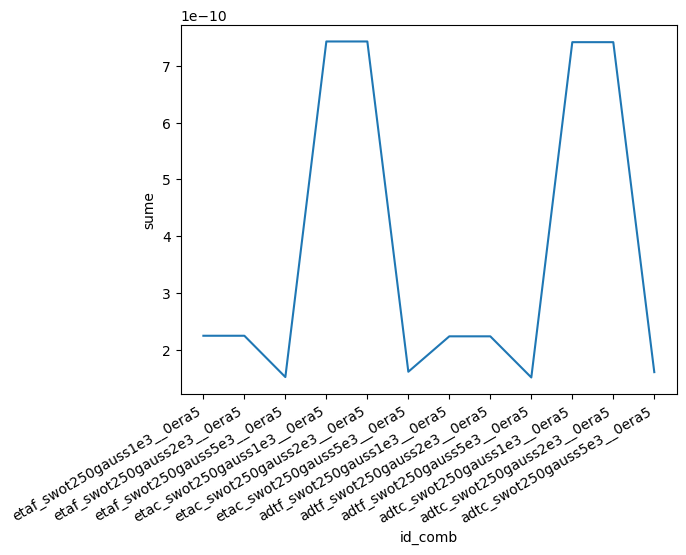

In [27]:
idc = ['etaf_swot250gauss1e3__0era5',
       'etaf_swot250gauss2e3__0era5',
       'etaf_swot250gauss5e3__0era5',
       'etac_swot250gauss1e3__0era5',
       'etac_swot250gauss2e3__0era5',
       'etac_swot250gauss5e3__0era5',
       'adtf_swot250gauss1e3__0era5',
       'adtf_swot250gauss2e3__0era5',
       'adtf_swot250gauss5e3__0era5',
       'adtc_swot250gauss1e3__0era5',
       'adtc_swot250gauss2e3__0era5',
       'adtc_swot250gauss5e3__0era5',
      ]
((DS.sume**2).sel(id_comb =idc).mean('row_number')).plot()
plt.xticks(rotation=30, ha='right')

([0, 1, 2, 3],
 [Text(0, 0, 'etaf_swot250gauss1e3__0era5'),
  Text(1, 0, 'etaf_swot250gauss2e3__0era5'),
  Text(2, 0, 'etaf_swot250gauss5e3__0era5'),
  Text(3, 0, 'etaf_swot250naive__0era5')])

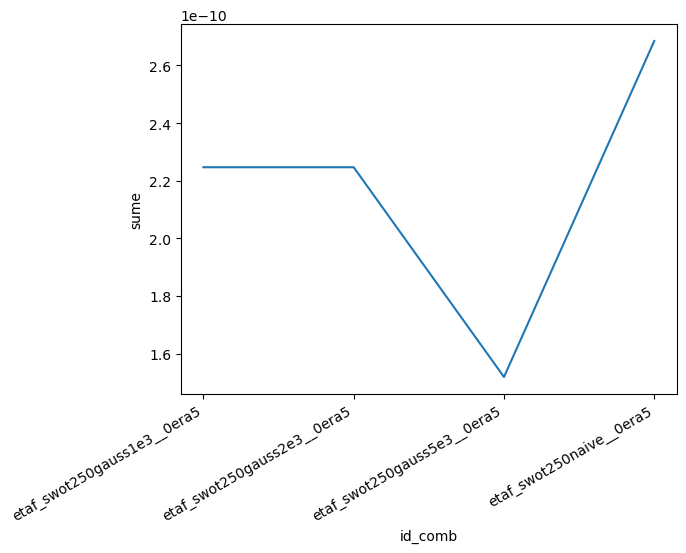

In [29]:
idc = ['etaf_swot250gauss1e3__0era5',
       'etaf_swot250gauss2e3__0era5',
       'etaf_swot250gauss5e3__0era5',
       'etaf_swot250naive__0era5',
      ]
((DS.sume**2).sel(id_comb =idc).mean('row_number')).plot()
plt.xticks(rotation=30, ha='right')

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'fromduacsv_swot250naive__0era5'),
  Text(1, 0, 'fromduacsv_swot250naive__15era5'),
  Text(2, 0, 'etaf_swot250naive__0era5'),
  Text(3, 0, 'etaf_swot250naive__15era5'),
  Text(4, 0, 'fromduacsv_swot250gauss5e3__0era5'),
  Text(5, 0, 'fromduacsv_swot250gauss5e3__15era5'),
  Text(6, 0, 'etaf_swot250gauss5e3__0era5'),
  Text(7, 0, 'etaf_swot250gauss5e3__15era5')])

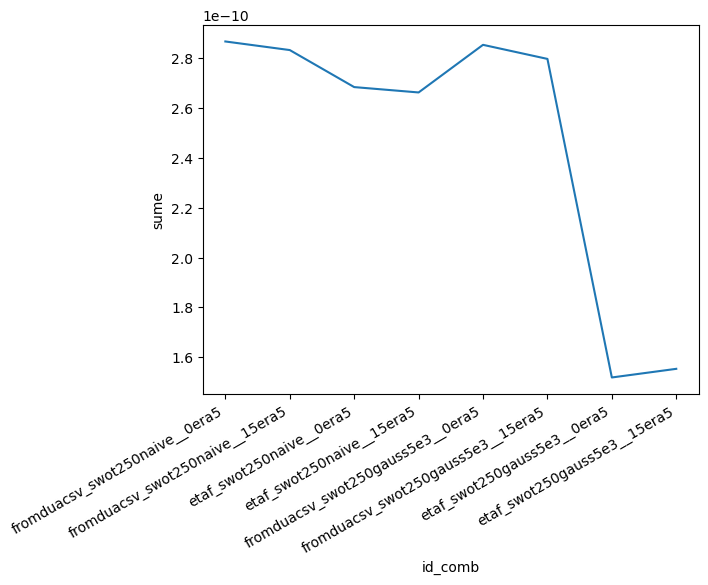

In [32]:
idc = ['fromduacsv_swot250naive__0era5',
       'fromduacsv_swot250naive__15era5',
       'etaf_swot250naive__0era5',
       'etaf_swot250naive__15era5',
       'fromduacsv_swot250gauss5e3__0era5',
       'fromduacsv_swot250gauss5e3__15era5',
       'etaf_swot250gauss5e3__0era5',
       'etaf_swot250gauss5e3__15era5']
((DS.sume**2).sel(id_comb =idc).mean('row_number')).plot()
plt.xticks(rotation=30, ha='right')